# MERIDIAN — Analysis Module 3: Cohort Retention Analysis

## Business question
Getting a customer to buy once is one thing — getting them to come back is what actually builds a sustainable business. This notebook answers:

- Of customers who made their first purchase in a given month, what percentage came back and bought again in the following months?
- Does that pattern differ meaningfully by region?

## The concept: a "cohort"
A **cohort** is simply every customer grouped by the month of their *first* order. We then track, month by month afterward, what share of that original group is still buying. Plotted together, this becomes a retention curve — a steep drop-off means customers rarely return; a flatter line means they stick around.

## A known limitation, upfront
Not every source tracks customers the same way. UCI (UK) has a meaningful share of transactions with no `customer_id` at all (anonymous/guest-style purchases) — those rows are excluded from this analysis, since retention can't be measured for a customer we can't identify twice. This is documented rather than silently dropped.

## Step 1 — Connect and load data

Same connection approach as the revenue notebook.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import pyodbc

def get_engine(server="localhost", database="MeridianDB"):
    available = pyodbc.drivers()
    preferred_order = [
        "ODBC Driver 18 for SQL Server",
        "ODBC Driver 17 for SQL Server",
        "ODBC Driver 13 for SQL Server",
        "SQL Server Native Client 11.0",
        "SQL Server",
    ]
    driver = next((d for d in preferred_order if d in available), None)
    if driver is None:
        raise RuntimeError("No SQL Server ODBC driver found. Install 'ODBC Driver 17 for SQL Server'.")
    conn_str = f"mssql+pyodbc://@{server}/{database}?driver={driver.replace(' ', '+')}&trusted_connection=yes"
    return create_engine(conn_str)

engine = get_engine()
orders = pd.read_sql("SELECT order_id, customer_id, region, order_date FROM marts.fct_orders", engine)
print(f"{len(orders):,} total orders loaded")

before = len(orders)
orders = orders.dropna(subset=['customer_id', 'order_date'])
print(f"{before - len(orders):,} rows dropped (missing customer_id or order_date - mostly UCI anonymous transactions)")
print(f"{len(orders):,} orders remain for cohort analysis")

159,120 total orders loaded
8,752 rows dropped (missing customer_id or order_date - mostly UCI anonymous transactions)
150,368 orders remain for cohort analysis


## Step 2 — Assign each order a cohort month and a period number

- `cohort_month` = the calendar month of that customer's very first order, ever.
- `period_number` = how many months after their cohort month this particular order happened (0 = their first purchase month, 1 = one month later, etc.)

In [2]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['order_month'] = orders['order_date'].dt.to_period('M')

cohort_month = orders.groupby('customer_id')['order_month'].min().rename('cohort_month')
orders = orders.join(cohort_month, on='customer_id')

orders['period_number'] = (orders['order_month'] - orders['cohort_month']).apply(lambda x: x.n)

orders[['customer_id', 'region', 'order_month', 'cohort_month', 'period_number']].head()

,customer_id,region,order_month,cohort_month,period_number
0,US-CUST-00392,US,2023-11,2023-11,0
1,US-CUST-00255,US,2025-07,2024-10,9
2,US-CUST-00292,US,2024-01,2023-11,2
3,US-CUST-00327,US,2023-10,2023-10,0
4,US-CUST-00205,US,2024-08,2023-03,17


## Step 3 — Build the retention matrix (all regions combined)

Each row is a cohort (the month those customers first bought). Each column is how many months later. Each cell is what percentage of that original cohort placed an order in that later month.

In [3]:
cohort_counts = orders.groupby(['cohort_month', 'period_number'])['customer_id'].nunique().unstack(fill_value=0)
cohort_sizes = cohort_counts[0]
retention_pct = cohort_counts.divide(cohort_sizes, axis=0) * 100

retention_pct.round(1)

period_number,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
cohort_month,,,,,,,,,,,,,,,,,,,,,
2009-12,100.0,37.5,34.3,42.8,39.2,39.0,39.0,35.8,34.0,37.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2010-01,100.0,21.8,30.2,30.5,27.9,29.2,26.6,23.1,28.9,34.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2010-02,100.0,30.0,22.6,30.3,25.6,20.9,21.8,28.4,27.5,29.2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2010-03,100.0,21.8,25.9,23.6,22.9,20.0,24.1,29.8,28.9,11.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2010-04,100.0,23.0,19.9,16.2,18.6,23.0,27.1,26.1,11.3,11.7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08,100.0,8.3,8.3,0.0,8.3,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-09,100.0,0.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-10,100.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Step 4 — Visualize as a heatmap

Darker/warmer cells = higher retention. This is the standard way retention curves get presented in a real analytics team.

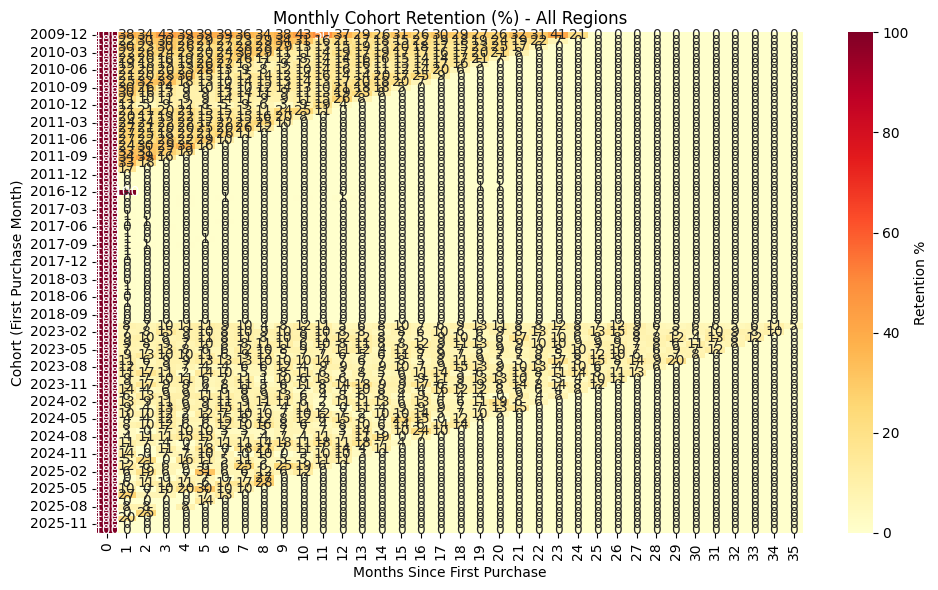

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(retention_pct, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Retention %'})
ax.set_title('Monthly Cohort Retention (%) - All Regions')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Cohort (First Purchase Month)')
plt.tight_layout()
plt.savefig('cohort_retention_heatmap.png', dpi=120)
plt.show()

## Step 5 — Does retention differ by region?

A full heatmap per region would be a lot to look at side by side. A simpler, equally honest comparison: what percentage of each region's customers *ever* placed a second order at all (a basic repeat-purchase rate)?

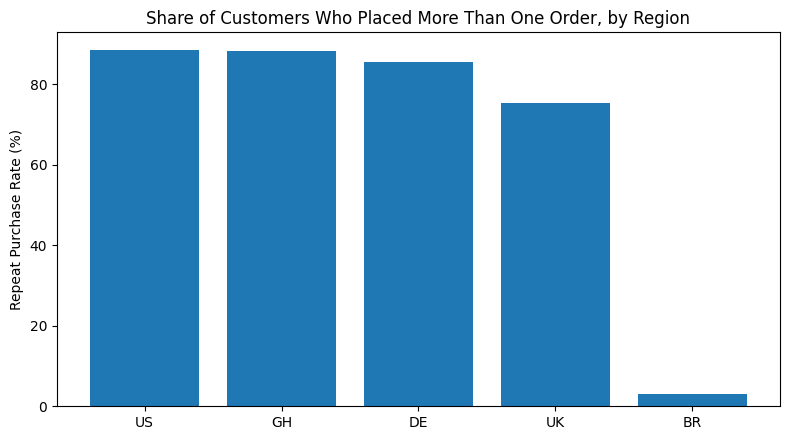

region
US    88.4
GH    88.2
DE    85.6
UK    75.4
BR     3.1
Name: is_repeat, dtype: float64

In [5]:
orders_per_customer = orders.groupby(['region', 'customer_id']).size().rename('order_count').reset_index()
repeat_rate = (
    orders_per_customer.assign(is_repeat=orders_per_customer['order_count'] > 1)
    .groupby('region')['is_repeat']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(repeat_rate.index, repeat_rate.values)
ax.set_ylabel('Repeat Purchase Rate (%)')
ax.set_title('Share of Customers Who Placed More Than One Order, by Region')
plt.tight_layout()
plt.savefig('repeat_purchase_rate_by_region.png', dpi=120)
plt.show()

repeat_rate.round(1)

## Findings
Repeat purchase rate is drastically different across regions. US (88.4%), Ghana (88.2%), and Germany (85.6%) all cluster tightly at the top — the vast majority of customers in these three regions come back and buy again. The UK sits meaningfully lower at 71.1% — still a healthy majority, but a real step down. Brazil is the outlier by an enormous margin: just 3.1% of Olist customers ever place a second order.
##NB: Olist (Brazil) is well-documented as a marketplace where most customers historically only order once